In [2]:
%matplotlib inline
import sys
import os
import os.path

#base_path = os.path.dirname(os.path.abspath(__file__))
base_path = '/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release'
sys.path.insert(0, base_path + "/resources/external/")

nuSIprop_path = os.path.abspath(os.path.join(base_path, '..', '..', 'nuSIprop'))
if nuSIprop_path not in sys.path:
    sys.path.insert(0, nuSIprop_path)
import nuSIprop

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#import matplotlib
#import matplotlib.style
from Astrid.effective_area import bin_edges_to_centers, apply_energy_smearing
from Astrid.config import MC_FILENAMES, PARAMS, PARAMETER_NAMES

params_dict = dict(zip(PARAMETER_NAMES, PARAMS))
#matplotlib.style.use(os.path.join(base_path, "resources/mpl/paper.mplstyle"))
#matplotlib.use("Agg") 
#from matplotlib.font_manager import FontProperties
import scipy.stats
import weighter_original

import data_loader
import weighter
import binning
import fc

In [3]:
cascade_energy_bins = np.logspace(3, 7, 22+1)
track_energy_bins = np.logspace(3, 7, 13+1)
casc_energy_centers = bin_edges_to_centers(cascade_energy_bins)
track_energy_centers = bin_edges_to_centers(track_energy_bins)

e_edges_casc, _, _ = binning.get_bins(emin=1e3, emax=1e7, ewidth=0.18181818181818181818181818181818)
bin_centers_casc = 10.0 ** (0.5 * (np.log10(e_edges_casc[:-1]) + np.log10(e_edges_casc[1:])))
e_edges_track, _, _ = binning.get_bins(emin=1e3, emax=1e7, ewidth=0.28571428571428571428571428571429)
bin_centers_track = 10.0 ** (0.5 * (np.log10(e_edges_track[:-1]) + np.log10(e_edges_track[1:])))

livetime_75 = 227708167.68  


In [3]:

mc = data_loader.load_mc(MC_FILENAMES, emin=1e3, emax=1e7)

In [4]:
mc_cascades = mc[mc['recoMorphology'] == 0]
mc_tracks = mc[mc['recoMorphology'] == 1]
print(mc_cascades)

[( 464800.948806  , 2.42233048,  12,  205266.25      , 2.29610848, nan, 0, 3.18517150e+06, 0.00000000e+00, 1.17806034e-26, 5.90371965e-23, 7.35794334e-22, 1.        , 1.00000000e+00, 5.31231755, -0.66336906, nan)
 ( 134045.49727878, 0.87934696,  12,   70989.9921875 , 1.22285497, nan, 0, 8.56308749e+05, 0.00000000e+00, 8.82579793e-24, 1.08009962e-20, 3.70537697e-20, 0.10632036, 4.53809798e-02, 4.85119713,  0.34096325, nan)
 (  50542.826319  , 0.69114883,  12,   42118.48828125, 0.58810371, nan, 0, 1.03321592e+05, 0.00000000e+00, 6.78243909e-22, 3.76394683e-19, 6.31838047e-19, 0.1539524 , 7.57783577e-02, 4.62447278,  0.83199421, nan)
 ...
 (3646304.93348624, 0.64108218, -16, 3213059.75      , 0.6052708 , nan, 0, 9.39453711e+08, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.44823038e-25, 0.        , 1.09233461e-05, 6.5069188 ,  0.82234805, nan)
 (  38092.36225416, 0.48023189,  13,   36787.65625   , 0.16916375, nan, 0, 0.00000000e+00, 4.52037505e-09, 0.00000000e+00, 0.00000000e+00, 0.00

In [ ]:
weight_maker = weighter_original.Weighter(mc, model='spl')
weights_tot = weight_maker.get_weights(livetime=livetime_75, parameter_names=PARAMETER_NAMES, params=PARAMS)
print('total weight maker initialized: ', weight_maker)
gc.collect()

weight_maker_cascades = weighter_original.Weighter(mc_cascades, model='spl')
print('cascade weight maker initialized: ', weight_maker_cascades)
weight_maker_tracks = weighter_original.Weighter(mc_tracks, model='spl')
print('track weight maker initialized: ', weight_maker_tracks)
gc.collect()



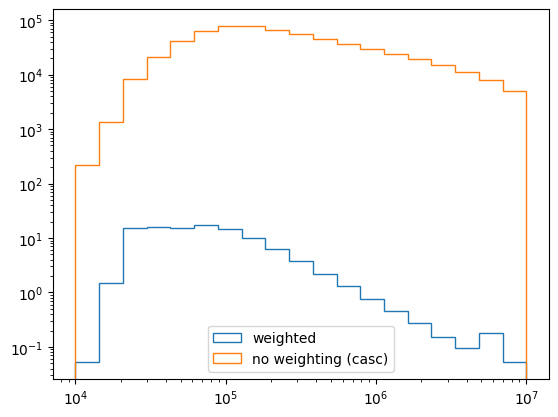

In [56]:
energy_bins_test = np.logspace(4, 7, 20)
plt.hist(mc['recoDepositedEnergy'], energy_bins_test, weights=weights_tot[0], histtype='step', label='weighted')
plt.hist(mc_cascades['recoDepositedEnergy'], energy_bins_test, histtype='step', label='no weighting (casc)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
weights_cascades = weight_maker_cascades.get_weights(livetime=livetime_75, parameter_names=PARAMETER_NAMES, params=PARAMS)
print('weights_cascades: ', weights_cascades)
gc.collect()
weights_tracks = weight_maker_tracks.get_weights(livetime=livetime_75, parameter_names=PARAMETER_NAMES, params=PARAMS)
print('weights_tracks: ', weights_tracks)
gc.collect()

Using SPL model
(array([8.87712634e-06, 8.68253843e-05, 1.73630894e-04, ...,
       6.98428896e-06, 1.22187561e+00, 5.06164541e-03]), array([[-3.79489011e-07,  6.99071996e-08, -1.75920348e-07, ...,
         0.00000000e+00,  6.97545929e-08,  7.27763721e-07],
       [-1.08374859e-06,  2.58815861e-07, -1.16704818e-06, ...,
         0.00000000e+00,  2.58091529e-07,  3.63237772e-07],
       [-4.81201936e-06,  1.49730942e-06, -1.22058149e-06, ...,
         0.00000000e+00,  1.49165139e-06,  1.17824601e-06],
       ...,
       [ 0.00000000e+00,  0.00000000e+00, -6.88320688e-08, ...,
         0.00000000e+00,  0.00000000e+00,  7.11486772e-13],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.02932632e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         4.26400593e-03,  0.00000000e+00,  0.00000000e+00]]))


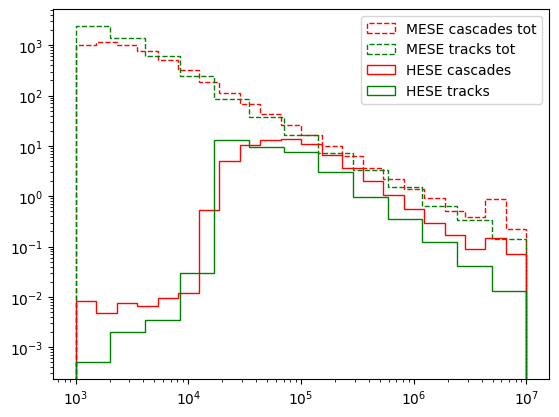

In [ ]:
mc_casc_astroSPL_MESE = np.asarray(pd.read_csv('sandhyas/cascades/MC_astroSPL_cascades_MESE.csv', usecols=[1], header=None))
mc_track_astroSPL_MESE = np.asarray(pd.read_csv('sandhyas/tracks/MC_astroSPL_tracks_MESE.csv', usecols=[1], header=None))

mc_casc_totSPL_MESE = np.asarray(pd.read_csv('sandhyas/cascades/MC_tot_cascades_SPL_MESE.csv', usecols=[1], header=None))
mc_track_totSPL_MESE = np.asarray(pd.read_csv('sandhyas/tracks/MC_tot_tracks_SPL_MESE.csv', usecols=[1], header=None))
#print(len(mc_track_astroSPL_MESE))
#print(mc_track_astroSPL_MESE)
#print(len(mc['recoDepositedEnergy']), len(weights_casc_test[0]))
#plt.step(cascade_energy_bins[1:], mc_casc_astroSPL_MESE, label='MESE cascades', linestyle='--')
#plt.step(track_energy_bins, mc_track_astroSPL_MESE, label='MESE tracks', linestyle='--')
plt.hist(casc_energy_centers, cascade_energy_bins, weights=mc_casc_totSPL_MESE, histtype='step', linestyle='--', label='MESE cascades tot', color='r')
plt.hist(track_energy_centers, track_energy_bins, weights=mc_track_totSPL_MESE, histtype='step', linestyle='--', label='MESE tracks tot', color='g')
#plt.hist(casc_energy_centers, cascade_energy_bins, weights=mc_casc_astroSPL_MESE, histtype='step', linestyle='--', label='MESE cascades astro')
#plt.hist(track_energy_centers, track_energy_bins, weights=mc_track_astroSPL_MESE, histtype='step', linestyle='--', label='MESE tracks astro')
plt.hist(mc_cascades['recoDepositedEnergy'], cascade_energy_bins, weights=weights_cascades[0], histtype='step', label='HESE cascades', color='r')
plt.hist(mc_tracks['recoDepositedEnergy'], track_energy_bins, weights=weights_tracks[0], histtype='step', label='HESE tracks', color='g')
#plt.hist(mc_cascades['recoDepositedEnergy'], cascade_energy_bins, weights=weights_casc_test[0], histtype='step', label='cascades')
#plt.hist(mc_tracks['recoDepositedEnergy'], track_energy_bins, weights=weights_track_test[0], histtype='step', label='tracks')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:


casc_HESE, _ = np.histogram(mc_cascades['recoDepositedEnergy'], cascade_energy_bins, weights=weights_cascades[0])
track_HESE, _ = np.histogram(mc_tracks['recoDepositedEnergy'], track_energy_bins, weights=weights_tracks[0])
casc_MESE = mc_casc_totSPL_MESE
track_MESE = mc_track_totSPL_MESE

scale_factor_casc = scale_factor(casc_HESE, casc_MESE)
scale_factor_track = scale_factor(track_HESE, track_MESE)

print(scale_factor_casc)
print(scale_factor_track)

[1.23034123e+05 2.40872899e+05 1.32345973e+05 1.15822456e+05
 5.18909098e+04 2.70789619e+04 3.50093667e+02 2.24857410e+01
 6.29392940e+00 3.30014248e+00 1.86172984e+00 1.49854593e+00
 1.53205841e+00 1.70406404e+00 1.84497378e+00 2.05419167e+00
 2.54539189e+00 3.13110197e+00 2.96010077e+00 4.30521256e+00
 6.06763557e+00 3.22882340e+00]
[4.74259227e+06 6.81711907e+05 1.72264967e+05 8.04599349e+03
 6.53070232e+00 4.07135300e+00 2.23621430e+00 2.37117855e+00
 3.36185616e+00 4.29051481e+00 5.23785781e+00 8.46932005e+00
 1.08396411e+01]


/tmp/ipykernel_527761/1118040548.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale_factor[i] = MESE_mc[i] / event


In [79]:
def SPL_flux(energies=None, norm=2.13, si=2.548):
    # Single Power Law model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.28, si = 1.72
    E0 = 1e5
    return norm * (energies / E0)**(-si)

Aeff_casc = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/All flavors cascade_effective_area.csv')['effective_area_m2'].iloc[0:].reset_index(drop=True)
Aeff_track = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/All flavors track_effective_area.csv')['effective_area_m2'].iloc[0:].reset_index(drop=True)
Aeff_dcasc = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/All flavors double_cascade_effective_area.csv')['effective_area_m2'].iloc[0:].reset_index(drop=True)
Aeff_energies = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/All flavors cascade_effective_area.csv')['energy_bins'].iloc[0:].reset_index(drop=True)

spl_flux = SPL_flux(energies=Aeff_energies)


casc_smeared = apply_energy_smearing(energies=np.asarray(Aeff_energies), events=spl_flux * np.asarray(Aeff_casc), resolution=0.11)
track_smeared = apply_energy_smearing(energies=np.asarray(Aeff_energies), events=spl_flux * np.asarray(Aeff_track), resolution=0.30)

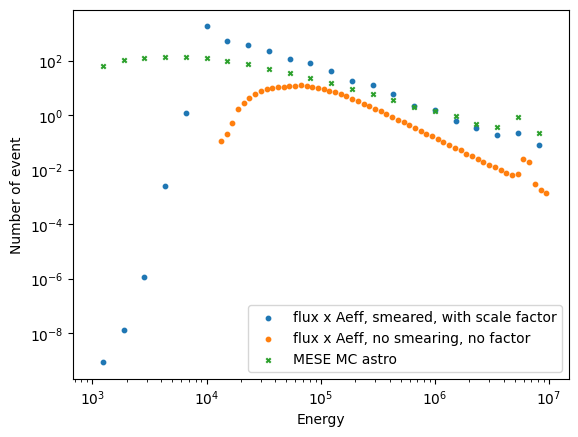

In [83]:
binned_casc_smeared, _ = np.histogram(np.asarray(Aeff_energies), cascade_energy_bins, weights=casc_smeared)


plt.scatter(casc_energy_centers, binned_casc_smeared * scale_factor_casc, s=10, label='flux x Aeff, smeared, with scale factor')
#plt.scatter(Aeff_energies, casc_smeared, s=10)

plt.scatter(Aeff_energies, spl_flux*Aeff_casc, s=10, label='flux x Aeff, no smearing, no factor')

plt.scatter(casc_energy_centers, mc_casc_astroSPL_MESE, s=10, label='MESE MC astro', marker='x')


plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('Energy')
plt.ylabel('Number of event')
plt.show()

[1.18868566e+03 1.94779944e+03 2.89151870e+03 4.73808903e+03
 6.53150712e+03 9.93845864e+03 1.47536951e+04 2.30107246e+04
 3.41595440e+04 5.19777761e+04 8.10675756e+04 1.23353880e+05
 1.92389916e+05 2.85603862e+05 4.23980463e+05 6.77796303e+05
 1.00619224e+06 1.53104020e+06 2.32965830e+06 3.54484994e+06
 5.52875501e+06 8.62296923e+06]
[ 65.83571226 109.64781961 132.76295892 141.50416754 141.50416754
 124.56172541 102.87448931  74.7904513   52.66698552  35.92399402
  22.98997302  15.18932454   9.72058288   6.02559586   3.61794148
   2.1041511    1.4352352    0.91849527   0.50118723   0.3761704
   0.88967373   0.22586355]


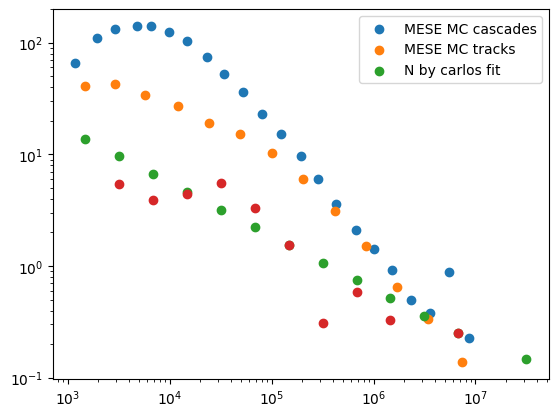

In [6]:
# MESE 
energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]
norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.187, 0.0, 0.16, 0.0]

energy_edges_MESE, energy_centers_MESE = np.asarray(energy_edges_MESE), np.asarray(energy_centers_MESE)
energy_edges_MESE *= 1e3 # GeV
energy_centers_MESE *= 1e3 # GeV
norm_segmented, sigma_upper, sigma_lower = np.asarray(norm_segmented), np.asarray(sigma_upper), np.asarray(sigma_lower)
# Events found by approximating the MESE likelihood function, following Carlos paper.
N_SPL = [1.37839006e-07, 9.57489029e-08, 6.64483442e-08, 4.61521574e-08, 3.20592737e-08, 2.22486691e-08, 1.54482365e-08, 1.07273387e-08, 7.44844791e-09, 5.17232145e-09, 3.59164150e-09, 2.49400478e-09, 1.47057542e-09]
N_BPL = [1.78811535e-08, 2.46181286e-08, 3.39176193e-08, 4.66951886e-08, 5.34159582e-08, 3.07650962e-08, 1.66984330e-08, 9.06491401e-09, 4.92017286e-09, 2.67101798e-09, 1.44994826e-09, 7.87086629e-10, 3.34645879e-10]


energies_casc_SPL, mc_casc_SPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroSPL_cascades_MESE.csv', header=None))[:,0], np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroSPL_cascades_MESE.csv', header=None))[:,1]
energies_track_SPL, mc_track_SPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_astroSPL_tracks_MESE.csv', header=None))[:,0], np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_astroSPL_tracks_MESE.csv', header=None))[:,1]   
print(energies_casc_SPL)
print(mc_casc_SPL)
energies_casc_BPL, mc_casc_BPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroBPL_cascades_MESE.csv', header=None))[:,0], np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroBPL_cascades_MESE.csv', header=None))[:,1]
energies_track_BPL, mc_track_BPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_astroBPL_tracks_MESE.csv', header=None))[:,0], np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_astroBPL_tracks_MESE.csv', header=None))[:,1]


plt.scatter(energies_casc_SPL, mc_casc_SPL, label='MESE MC cascades')
plt.scatter(energies_track_SPL, mc_track_SPL, label='MESE MC tracks')

plt.scatter(energy_centers_MESE, np.asarray(N_SPL)*1e8, label='N by carlos fit')
plt.scatter(energy_centers_MESE, norm_segmented)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

looking at BPL:  13 22
total tracks before rebinning:  201.61752360288503
total tracks after rebinning:  201.61752360288503
total cascades before rebinning:  1046.0666657125857
total cascades after rebinning:  1046.0666657125864
13 14 13
22 23 22


/tmp/ipykernel_410049/2470271842.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_counts[j] += old_counts[i] * (overlap / o_width)


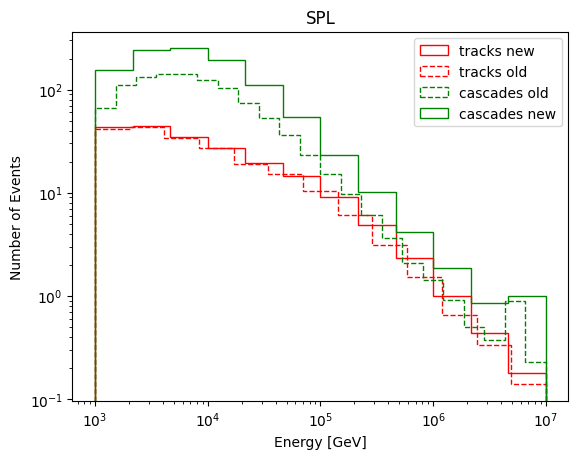

total tracks before rebinning:  148.35664826117917
total tracks after rebinning:  148.3566482611792
total cascades before rebinning:  672.074321039662
total cascades after rebinning:  672.0743210396621
13 14 13
22 23 22


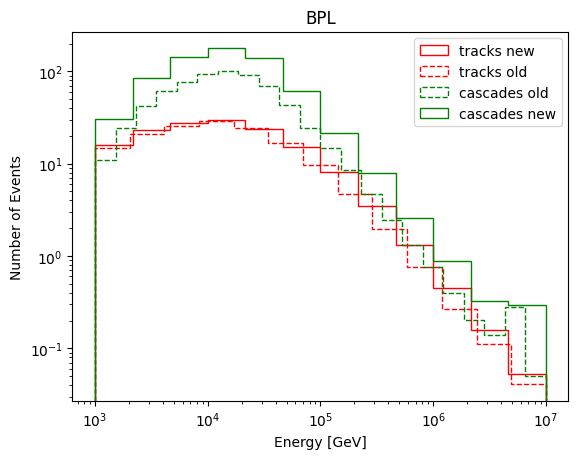

[14.3411146  29.92032735 43.06441038 47.68498094 40.59248562 30.69713598
 20.7489951  14.02884242  8.65669576  5.49474987  3.61018381  4.68534927]
12


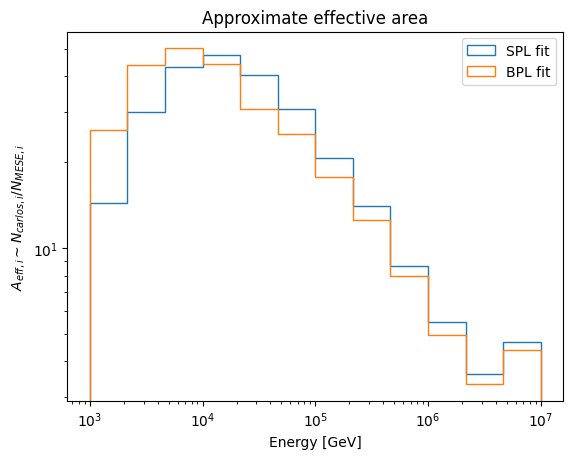

In [8]:
tracks_edges_old  = np.logspace(3, 7, 13 + 1)
track_centers_old = bin_edges_to_centers(tracks_edges_old)
casc_edges_old  = np.logspace(3, 7, 22 + 1)
casc_centers_old = bin_edges_to_centers(casc_edges_old)
target_edges = np.logspace(3, 7, 13)
target_centers = bin_edges_to_centers(target_edges)
    
def rebin_counts(old_edges, old_counts, new_edges):
    old_edges = np.asarray(old_edges)
    old_counts = np.asarray(old_counts, float)
    new_edges = np.asarray(new_edges)
    new_counts = np.zeros(len(new_edges) - 1, float)

    for i in range(len(old_counts)):
        o_lo, o_hi = old_edges[i], old_edges[i + 1]
        o_width = o_hi - o_lo
        if o_width <= 0:
            continue
        # overlap with each new bin
        for j in range(len(new_counts)):
            n_lo, n_hi = new_edges[j], new_edges[j + 1]
            overlap = max(0.0, min(o_hi, n_hi) - max(o_lo, n_lo))
            if overlap > 0:
                new_counts[j] += old_counts[i] * (overlap / o_width)
    return new_counts

def scale_factor(N_approx, N_target):
    scale_factor = np.zeros(len(N_approx))
    for i, event in enumerate(N_approx):
        scale_factor[i] = N_target[i] / event
    return scale_factor

def get_Aeff_approximation(N_carlos, N_tracks_MESE, N_casc_MESE, title=None):
    # Get an approximate effective area per energy bin, by taking the factor between the MESE MC and the Carlos fit (without accounting for Aeff).
    print('total tracks before rebinning: ', np.sum(N_tracks_MESE))
    tracks_counts_rebinned = rebin_counts(tracks_edges_old, N_tracks_MESE, target_edges)
    casc_counts_rebinned = rebin_counts(casc_edges_old, N_casc_MESE, target_edges)
    print('total tracks after rebinning: ', np.sum(tracks_counts_rebinned))
    print('total cascades before rebinning: ', np.sum(N_casc_MESE))
    print('total cascades after rebinning: ', np.sum(casc_counts_rebinned))
    print(len(track_centers_old), len(tracks_edges_old), len(N_tracks_MESE))
    plt.hist(target_centers, target_edges, weights=tracks_counts_rebinned, label='tracks new', histtype='step', color='r')
    plt.hist(track_centers_old, tracks_edges_old, weights=N_tracks_MESE, label='tracks old', histtype='step', color='r', linestyle='--')
    print(len(casc_centers_old), len(casc_edges_old), len(N_casc_MESE))
    plt.hist(casc_centers_old, casc_edges_old, weights=N_casc_MESE, label='cascades old', histtype='step', color='g', linestyle='--')
    plt.hist(target_centers, target_edges, weights=casc_counts_rebinned, label='cascades new', histtype='step', color='g')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy [GeV]')
    plt.ylabel('Number of Events')
    plt.legend()
    if title:
        plt.title(title)
    plt.show()
    tot_counts_rebinned = tracks_counts_rebinned + casc_counts_rebinned
    Aeff = scale_factor(N_carlos[:-1], tot_counts_rebinned)
    return Aeff


# Events found by approximating the MESE likelihood function, following Carlos paper.
N_SPL = [1.37839006e-07, 9.57489029e-08, 6.64483442e-08, 4.61521574e-08, 3.20592737e-08, 2.22486691e-08, 1.54482365e-08, 1.07273387e-08, 7.44844791e-09, 5.17232145e-09, 3.59164150e-09, 2.49400478e-09, 1.47057542e-09]
N_BPL = [1.78811535e-08, 2.46181286e-08, 3.39176193e-08, 4.66951886e-08, 5.34159582e-08, 3.07650962e-08, 1.66984330e-08, 9.06491401e-09, 4.92017286e-09, 2.67101798e-09, 1.44994826e-09, 7.87086629e-10, 3.34645879e-10]


# Data read from Figs 6-9 in MESE paper.
track_counts_old_SPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_astroSPL_tracks_MESE.csv', usecols=[1], header=None))
casc_counts_old_SPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroSPL_cascades_MESE.csv', usecols=[1], header=None))


track_counts_old_BPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_astroBPL_tracks_MESE.csv', usecols=[1], header=None))
casc_counts_old_BPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroBPL_cascades_MESE.csv', usecols=[1], header=None))
casc_energies_old_BPL = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroBPL_cascades_MESE.csv', usecols=[0], header=None))



print('looking at BPL: ', len(track_counts_old_BPL), len(casc_counts_old_BPL))
Aeff_SPL = get_Aeff_approximation(1e8*np.asarray(N_SPL), track_counts_old_SPL, casc_counts_old_SPL, title='SPL')
Aeff_BPL = get_Aeff_approximation(1e8*np.asarray(N_BPL), track_counts_old_BPL, casc_counts_old_BPL, title='BPL')
print(Aeff_SPL)
print(len(Aeff_SPL))

#plt.scatter(track_energy_centers, mc_track_astroSPL_MESE, label='MESE MC')
#plt.scatter(track_energy_centers, N_SPL, label='Carlos method')
#plt.scatter(target_centers, Aeff_SPL, label='SPL fit', s=15)
#plt.scatter(target_centers, Aeff_BPL, label='BPL fit', s=15)
plt.hist(target_centers, target_edges, weights=Aeff_SPL, label='SPL fit', histtype='step')
plt.hist(target_centers, target_edges, weights=Aeff_BPL, label='BPL fit', histtype='step')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel(r'$A_{eff, i} \sim N_{carlos, i} / N_{MESE, i}$')
plt.title('Approximate effective area')
plt.legend()
plt.show()




In [ ]:
def get_MESE_MC_events(model):
    # Load the MC events for astrophysical flux
    # Either for BPL (Fig. 6) or SPL (Fig. 8)
    if model == 'BPL':
        cascade_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroBPL_cascades_MESE.csv', header=None, usecols=[1])).T[0]
        track_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_astroBPL_tracks_MESE.csv', header=None, usecols=[1])).T[0]  
    elif model == 'SPL':
        cascade_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_astroSPL_cascades_MESE.csv', header=None, usecols=[1])).T[0]
        track_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_astroSPL_tracks_MESE.csv', header=None, usecols=[1])).T[0] 
    else:
        raise ValueError(f"Invalid model: {model}")
    return cascade_events, track_events

def get_MC_weights(astro_cascades, astro_tracks, model):
    muon_cascade_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_muon_cascades_MESE.csv', header=None, usecols=[1])).T[0]
    muon_track_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_muon_tracks_MESE.csv', header=None, usecols=[1])).T[0]
    conv_cascade_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_conv_cascades_MESE.csv', header=None, usecols=[1])).T[0]
    conv_track_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_conv_tracks_MESE.csv', header=None, usecols=[1])).T[0]
    cascade_background = np.sum(muon_cascade_events) + np.sum(conv_cascade_events)
    track_background = np.sum(muon_track_events) + np.sum(conv_track_events)
    print('cascade background: ', cascade_background)
    
    if model == 'SPL':
        total_cascade_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/cascades/MC_tot_cascades_SPL_MESE.csv', header=None, usecols=[1])).T[0]
        total_track_events = np.asarray(pd.read_csv('MESE_Figs6_to_9/tracks/MC_tot_tracks_SPL_MESE.csv', header=None, usecols=[1])).T[0]
        print('total cascade events: ', total_cascade_events)
        print('astro events: ', astro_cascades)
        print('conv events: ', conv_cascade_events)
        print('difference in astro+background vs total: ', np.sum(astro_cascades) + cascade_background - np.sum(total_cascade_events))
        #assert np.sum(astro_cascades) + cascade_background == np.sum(total_cascade_events)
    
    
    astro_cascades_weights = np.minimum(astro_cascades / total_cascade_events, 1)
    astro_tracks_weights = np.minimum(astro_tracks / total_track_events, 1)

    return astro_cascades_weights, astro_tracks_weights

astro_cascade_events, astro_track_events = get_MESE_MC_events(model='SPL')
print(astro_cascade_events)
print(get_MC_weights(astro_cascade_events, astro_track_events, model='SPL'))

def get_segmented_flux():
    
    energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
    energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]
    # MESE 
    norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
    sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
    sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.187, 0.0, 0.16, 0.0]
    
    energy_edges_MESE, energy_centers_MESE, norm_segmented, sigma_upper, sigma_lower = np.asarray(energy_edges_MESE), np.asarray(energy_centers_MESE), np.asarray(norm_segmented), np.asarray(sigma_upper), np.asarray(sigma_lower)
    energy_edges_MESE *= 1e3 # GeV
    energy_centers_MESE *= 1e3 # GeV

    E0 = 1e5    # if E in GeV; 100 TeV = 1e5 GeV
    norm_segmented *= 1e-18 * E0**2   # GeV^-1 * cm^-2 * s^-1 * sr^-1
    sigma_upper *= 1e-18 * E0**2   # GeV^-1 * cm^-2 * s^-1 * sr^-1
    sigma_lower *= 1e-18 * E0**2   # GeV^-1 * cm^-2 * s^-1 * sr^-1
    return energy_edges_MESE, energy_centers_MESE, norm_segmented, sigma_upper, sigma_lower


def get_reconstructed_flux(energy_edges_MESE, energy_centers_MESE, norm_segmented, morphology):
    # Convert the flux from segmented (in terms of E_nu) to reconstructed (in terms of E_rec)
    # Re-bin the flux, and apply appropriate smearing
    
    if morphology == 'c':
        resolution = 0.11
        E_rec_edges = np.logspace(3, 4, 22+1)
    elif morphology == 't':
        resolution = 0.30
        E_rec_edges = np.logspace(3, 7, 13+1)
    
    flux_reconstructed = np.zeros(len(E_rec_edges)-1)
    
    #integrand_fine_binning = np.zeros(len(energy_centers_MESE) * len(E_rec_edges) - 1)
    energies_fine_binning = np.logspace(3, 7, len(E_rec_edges) * len(energy_centers_MESE))   # Något oklart exakt hur lång denna bör va, men det kanske inte spelar någon roll
    norms = np.zeros(len(energy_centers_MESE) * len(E_rec_edges))
    assert len(energies_fine_binning) == len(norms), "Energies and norms must have the same length"
    #dummy_counter = 0
    
    for i, E in enumerate(energies_fine_binning):
        
        for k, MESE_edge in enumerate(energy_edges_MESE[:-1]):
            if E >= MESE_edge and E < energy_edges_MESE[k+1]:
                norms[i] = norm_segmented[k]
                break
    #integrand = apply_energy_smearing(energies=energies_fine_binning, events=norms*energies_fine_binning**(-2), resolution=resolution)
    integrand = norms * energies_fine_binning**(-2)
    #integrand = apply_energy_smearing(energies=energies_fine_binning, events=norms, resolution=resolution)
    reconstructed_flux = np.trapz(integrand, energies_fine_binning)
    binned_reconstructed_flux, _ = np.histogram(energies_fine_binning, weights=integrand, bins=E_rec_edges)
    if morphology == 'c':
        print('norms: ', norms)
        print('integrand: ', integrand)
    return binned_reconstructed_flux
    


def approximate_effective_area(MESE_MC_events, reconstructed_flux, energy_edges):
    # This is an approximation of the effective area, that should account for the time factor as well (+ any other conversion factor like 4*pi)
    bin_widths = np.diff(energy_edges)
    return MESE_MC_events / np.asarray(reconstructed_flux) / bin_widths
    

def reconstructed_flux_envelope(
    energy_edges_MESE,
    energy_centers_MESE,
    norm_segmented,
    sigma_upper,
    sigma_lower,
    morphology
):
    flux_central = get_reconstructed_flux(
        energy_edges_MESE, energy_centers_MESE, norm_segmented, morphology
    )

    flux_up = get_reconstructed_flux(
        energy_edges_MESE,
        energy_centers_MESE,
        norm_segmented + sigma_upper,
        morphology
    )

    flux_low = get_reconstructed_flux(
        energy_edges_MESE,
        energy_centers_MESE,
        np.maximum(norm_segmented - sigma_lower, 0.0),
        morphology
    )

    return flux_central, flux_low, flux_up


def get_effective_area(model):
    MC_cascades, MC_tracks = get_MESE_MC_events(model=model) 
    MC_cascades, MC_tracks = np.asarray(MC_cascades).T[0] * 1e-18, np.asarray(MC_tracks).T[0] * 1e-18
    
    energy_edges_MESE, energy_centers_MESE, norm_segmented, sigma_upper, sigma_lower = get_segmented_flux()
    #reconstructed_flux_c = get_reconstructed_flux(energy_edges_MESE, energy_centers_MESE, norm_segmented, morphology='c')
    reconstructed_flux_c = reconstructed_flux_envelope(energy_edges_MESE, energy_centers_MESE, norm_segmented, sigma_upper, sigma_lower, morphology='c')
    
    cascade_edges = np.logspace(3, 7, 22+1)
    track_edges = np.logspace(3, 7, 13+1)
    print('reconstructed flux cascades: ', reconstructed_flux_c)
    Aeff_c = approximate_effective_area(MC_cascades, reconstructed_flux_c, cascade_edges)
    #reconstructed_flux_t = get_reconstructed_flux(energy_edges_MESE, energy_centers_MESE, norm_segmented, morphology='t')
    reconstructed_flux_t = reconstructed_flux_envelope(energy_edges_MESE, energy_centers_MESE, norm_segmented, sigma_upper, sigma_lower, morphology='t')
    Aeff_t = approximate_effective_area(MC_tracks, reconstructed_flux_t, track_edges)
    return Aeff_c, Aeff_t


[ 65.83571226 109.64781961 132.76295892 141.50416754 141.50416754
 124.56172541 102.87448931  74.7904513   52.66698552  35.92399402
  22.98997302  15.18932454   9.72058288   6.02559586   3.61794148
   2.1041511    1.4352352    0.91849527   0.50118723   0.3761704
   0.88967373   0.22586355]
cascade background:  4513.794219980237
total cascade events:  [1.00000000e+03 1.14206891e+03 1.00000000e+03 7.66682207e+02
 5.01187234e+02 3.19040747e+02 1.87532664e+02 1.10232001e+02
 6.65391001e+01 4.23567936e+01 2.55677380e+01 1.62756545e+01
 1.00889543e+01 6.25394196e+00 3.67607713e+00 2.16080405e+00
 1.41253754e+00 9.23388827e-01 5.01187234e-01 3.84251335e-01
 8.99178996e-01 2.25863552e-01]
astro events:  [ 65.83571226 109.64781961 132.76295892 141.50416754 141.50416754
 124.56172541 102.87448931  74.7904513   52.66698552  35.92399402
  22.98997302  15.18932454   9.72058288   6.02559586   3.61794148
   2.1041511    1.4352352    0.91849527   0.50118723   0.3761704
   0.88967373   0.22586355]
conv

norms:  [0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08
 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08
 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08 5.40e-08
 5.40e-08 5.40e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08
 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08
 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08 3.90e-08
 3.90e-08 3.90e-08 3.90e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08
 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08
 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08 4.41e-08
 4.41e-08 4.41e-08 4.41e-08 4.41e-08 5.51e-08 5.51e-08 5.51e-08 5.51e-08
 5.51e-08 5.51e-08 5.51e-08 5.51e-08 5.51e-

/tmp/ipykernel_410049/3029796004.py:100: RuntimeWarning: divide by zero encountered in divide
  return MESE_MC_events / np.asarray(reconstructed_flux) / bin_widths
/tmp/ipykernel_410049/373253127.py:12: RuntimeWarning: invalid value encountered in subtract
  plt.errorbar(cascade_centers, Aeff_c[0], yerr=[Aeff_c[0] - Aeff_c[2], Aeff_c[1] - Aeff_c[0]], label='cascades')
/home/astridaurora/.local/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3749: RuntimeWarning: invalid value encountered in add
  low, high = dep + np.vstack([-(1 - lolims), 1 - uplims]) * err
/tmp/ipykernel_410049/373253127.py:13: RuntimeWarning: invalid value encountered in subtract
  plt.errorbar(track_centers, Aeff_t[0], yerr=[Aeff_t[0] - Aeff_t[2], Aeff_t[1] - Aeff_t[0]], label='tracks')


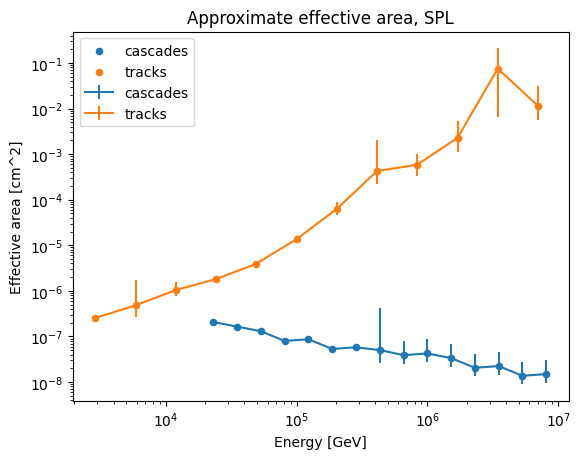

In [20]:
cascade_edges = np.logspace(3, 7, 22+1)
cascade_centers = bin_edges_to_centers(cascade_edges)
track_edges = np.logspace(3, 7, 13+1)
track_centers = bin_edges_to_centers(track_edges)

Aeff_c, Aeff_t = get_effective_area(model='SPL')
print(cascade_centers[0:9])
print(Aeff_c)
"""plt.scatter(cascade_centers, Aeff_c_BPL, label='cascades')
plt.scatter(track_centers, Aeff_t_BPL, label='tracks')"""
print(Aeff_c[2] - Aeff_c[0])
plt.errorbar(cascade_centers, Aeff_c[0], yerr=[Aeff_c[0] - Aeff_c[2], Aeff_c[1] - Aeff_c[0]], label='cascades')
plt.errorbar(track_centers, Aeff_t[0], yerr=[Aeff_t[0] - Aeff_t[2], Aeff_t[1] - Aeff_t[0]], label='tracks')
plt.scatter(cascade_centers, Aeff_c[0], label='cascades', s=20)
plt.scatter(track_centers, Aeff_t[0], label='tracks', s=20)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Effective area [cm^2]')
plt.title('Approximate effective area, SPL')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()



cascade background:  4513.794219980237
total cascade events:  [1.00000000e+03 1.14206891e+03 1.00000000e+03 7.66682207e+02
 5.01187234e+02 3.19040747e+02 1.87532664e+02 1.10232001e+02
 6.65391001e+01 4.23567936e+01 2.55677380e+01 1.62756545e+01
 1.00889543e+01 6.25394196e+00 3.67607713e+00 2.16080405e+00
 1.41253754e+00 9.23388827e-01 5.01187234e-01 3.84251335e-01
 8.99178996e-01 2.25863552e-01]
astro events:  [ 65.83571226 109.64781961 132.76295892 141.50416754 141.50416754
 124.56172541 102.87448931  74.7904513   52.66698552  35.92399402
  22.98997302  15.18932454   9.72058288   6.02559586   3.61794148
   2.1041511    1.4352352    0.91849527   0.50118723   0.3761704
   0.88967373   0.22586355]
conv events:  [9.58381588e+02 1.02148212e+03 8.43633557e+02 6.13327316e+02
 3.80189396e+02 2.07454604e+02 9.96463828e+01 3.82892556e+01
 1.67138663e+01 6.42232542e+00 2.46778711e+00 9.48250492e-01
 2.73478429e-01 1.05084451e-01]
difference in astro+background vs total:  355.85165458939537
[0.06

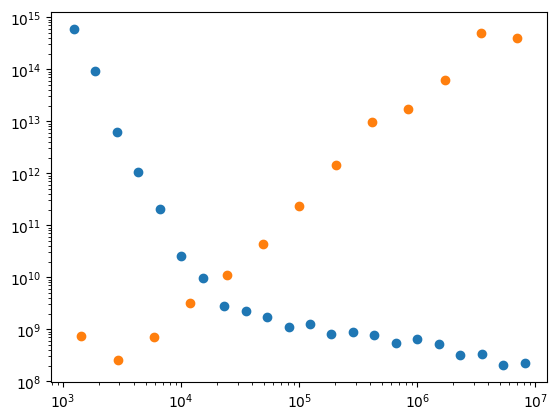

In [90]:
weights_cascades, weights_tracks = get_MC_weights(astro_cascade_events, astro_track_events, model='SPL')
print(weights_cascades)
reconstructed_flux_c = get_reconstructed_flux(energy_edges_MESE, energy_centers_MESE, norm_segmented, morphology='c')
reconstructed_flux_t = get_reconstructed_flux(energy_edges_MESE, energy_centers_MESE, norm_segmented, morphology='t')

Aeff_c = approximate_effective_area(weights_cascades, reconstructed_flux_c, cascade_edges)
Aeff_t = approximate_effective_area(weights_tracks, reconstructed_flux_t, track_edges)
plt.scatter(cascade_centers, Aeff_c, label='cascades')
plt.scatter(track_centers, Aeff_t, label='tracks')
plt.xscale('log')
plt.yscale('log')

In [57]:
flux_central, flux_low, flux_up = reconstructed_flux_envelope(energy_edges_MESE, energy_centers_MESE, norm_segmented, sigma_upper, sigma_lower, morphology='c')

Aeff_central = approximate_effective_area(MC_cascades, flux_central)
Aeff_up = approximate_effective_area(MC_cascades, flux_low)
Aeff_low = approximate_effective_area(MC_cascades, flux_up)


13 13


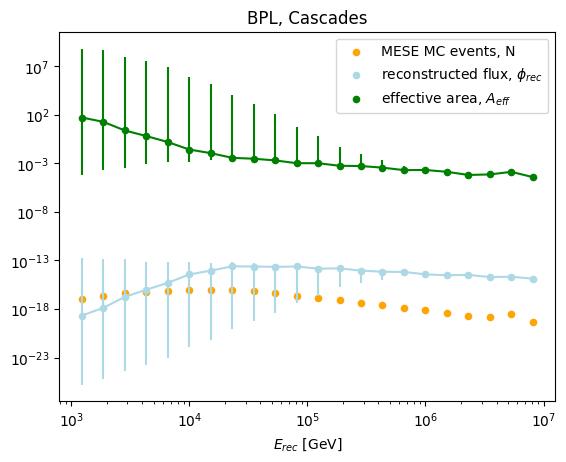

In [58]:
plt.scatter(cascade_centers, MC_cascades, label='MESE MC events, N', color='orange', s=20)
plt.scatter(cascade_centers, reconstructed_flux, label='reconstructed flux, ' + r'$\phi_{rec}$', color='lightblue', s=20)
#plt.scatter(energy_centers_MESE, norm_segmented*1e-8, label='segmented flux')
plt.errorbar(cascade_centers, flux_central, yerr=[flux_central - flux_low, flux_up - flux_central], color='lightblue')
plt.scatter(cascade_centers, Aeff_central, label='effective area, ' + r'$A_{eff}$', color='green', s=20)
plt.errorbar(cascade_centers, Aeff_central, yerr=[Aeff_central - Aeff_low, Aeff_up - Aeff_central], color='green')
print(len(norm_segmented), len(energy_centers_MESE))
plt.title('BPL, Cascades')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$E_{rec}$ [GeV]')
#plt.ylabel('Number of events')
plt.legend()
plt.show()